# Decision Tree Tuning

| | |
|---|---|
| **Algorithm** | DecisionTreeClassifier |
| **Dataset** | Wine Quality |
| **Task** | Binary Classification (quality >= 6) |
| **Metric** | CV Accuracy, CV F1 — 5-fold StratifiedKFold |

## 튜닝 포인트

| # | 튜닝 | 내용 | 기대 효과 |
|---|---|---|---|
| 1 | **GridSearchCV** | max_depth / min_samples_split / min_samples_leaf / criterion | 최적 트리 구조 탐색 |
| 2 | **CCP Pruning** | `ccp_alpha`로 가지치기 | 복잡한 트리 단순화 → 과적합 방지 |

## Imports
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

## Data Loading
---
- `wine.csv`: Red wine quality 데이터 (1,599 samples)
- target: `quality >= 6` → 1 (Good), 아니면 0 (Bad)

In [2]:
df = pd.read_csv('../datasets/wine.csv')
print(df.shape)
df.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
df['target'] = (df['quality'] >= 6).astype(int)
print(df['target'].value_counts())

feature_names = df.drop(columns=['quality', 'target']).columns.tolist()
X = df.drop(columns=['quality', 'target']).values
y = df['target'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

target
1    621
0    522
Name: count, dtype: int64


## Base Model
---
- DecisionTreeClassifier(max_depth=5), 나머지 기본값

In [4]:
base_acc = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42), X, y, cv=cv, scoring='accuracy').mean()
base_f1  = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42), X, y, cv=cv, scoring='f1').mean()
print(f'Base — CV Accuracy: {base_acc:.4f}  CV F1: {base_f1:.4f}')

Base — CV Accuracy: 0.7200  CV F1: 0.7395


## Tuning 1: GridSearchCV
---

| 파라미터 | 역할 | 작을 때 | 클 때 |
|---|---|---|---|
| `max_depth` | 트리 최대 깊이 | 단순 모델, 과소적합 | 복잡 모델, 과적합 |
| `min_samples_split` | 분기 최소 sample 수 | 작은 그룹도 분기 → 과적합 | 분기 억제 → 정규화 |
| `min_samples_leaf` | leaf 노드 최소 sample 수 | 단일 sample도 leaf 가능 → 과적합 | leaf 크기 강제 → 일반화 |
| `criterion` | 분기 기준 | gini: 지니 불순도 | entropy: 정보 이득 |

In [5]:
param_grid = {
    'max_depth':         [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'criterion':         ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid, cv=cv, scoring='f1', n_jobs=-1
)
grid.fit(X, y)

print(f'Best params : {grid.best_params_}')
print(f'Best CV F1  : {grid.best_score_:.4f}')

grid_acc = cross_val_score(grid.best_estimator_, X, y, cv=cv, scoring='accuracy').mean()
grid_f1  = grid.best_score_

Best params : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1  : 0.7585


## Tuning 2: Cost-Complexity Pruning (ccp_alpha)
---
- 손실 함수: `R_alpha(T) = R(T) + alpha * |T|`
  - `R(T)`: 불순도 합계, `|T|`: leaf 노드 수
- alpha 증가 → leaf 수를 줄이는 방향으로 가지치기 → 단순한 트리
- `cost_complexity_pruning_path()`로 alpha 후보를 얻어 최적값을 선택한다.

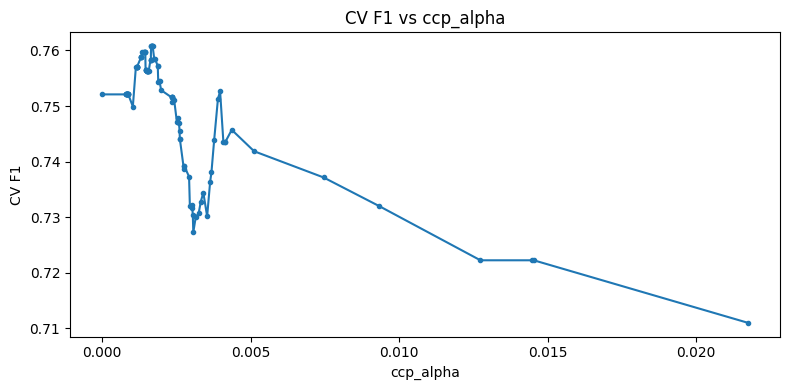

Best alpha: 0.001642


In [6]:
path   = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X, y)
alphas = path.ccp_alphas[:-1]

test_f1s = []
for alpha in alphas:
    f1 = cross_val_score(DecisionTreeClassifier(ccp_alpha=alpha, random_state=42),
                         X, y, cv=cv, scoring='f1').mean()
    test_f1s.append(f1)

plt.figure(figsize=(8, 4))
plt.plot(alphas, test_f1s, marker='.')
plt.xlabel('ccp_alpha')
plt.ylabel('CV F1')
plt.title('CV F1 vs ccp_alpha')
plt.tight_layout()
plt.show()

best_alpha = alphas[test_f1s.index(max(test_f1s))]
print(f'Best alpha: {best_alpha:.6f}')

pruned_acc = cross_val_score(DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42),
                              X, y, cv=cv, scoring='accuracy').mean()
pruned_f1  = max(test_f1s)

Tree depth : 13
Leaf nodes : 94


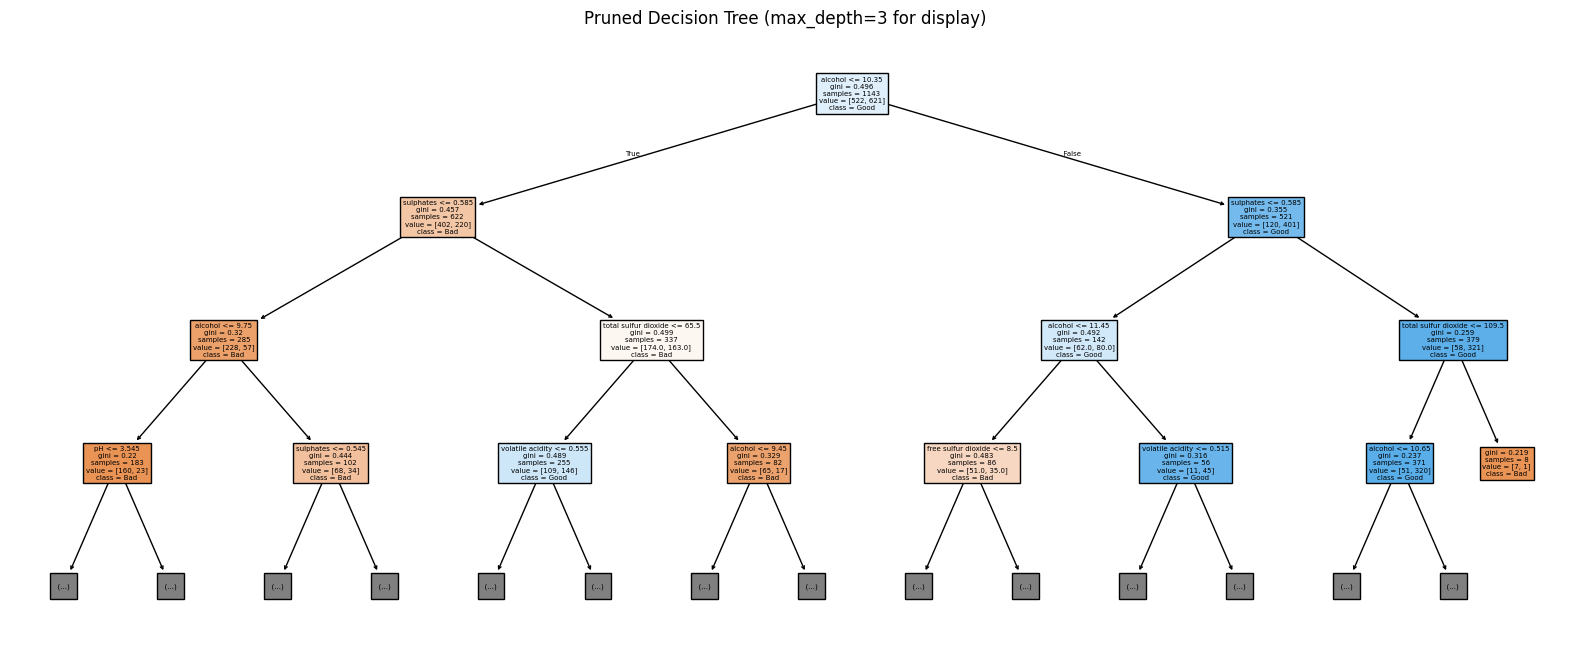

In [7]:
pruned_model = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
pruned_model.fit(X, y)
print(f'Tree depth : {pruned_model.get_depth()}')
print(f'Leaf nodes : {pruned_model.get_n_leaves()}')

plt.figure(figsize=(20, 8))
plot_tree(pruned_model, feature_names=feature_names, class_names=['Bad', 'Good'], filled=True, max_depth=3)
plt.title('Pruned Decision Tree (max_depth=3 for display)')
plt.show()

## 결과 비교
---
- 모든 모델을 동일한 5-fold StratifiedKFold CV로 평가

                 Model  CV Accuracy    CV F1 Acc Delta F1 Delta
    Base (max_depth=5)     0.720045 0.739492   +0.0000  +0.0000
Tuning 1: GridSearchCV     0.736662 0.758488   +0.0166  +0.0190
 Tuning 2: CCP Pruning     0.739290 0.760778   +0.0192  +0.0213


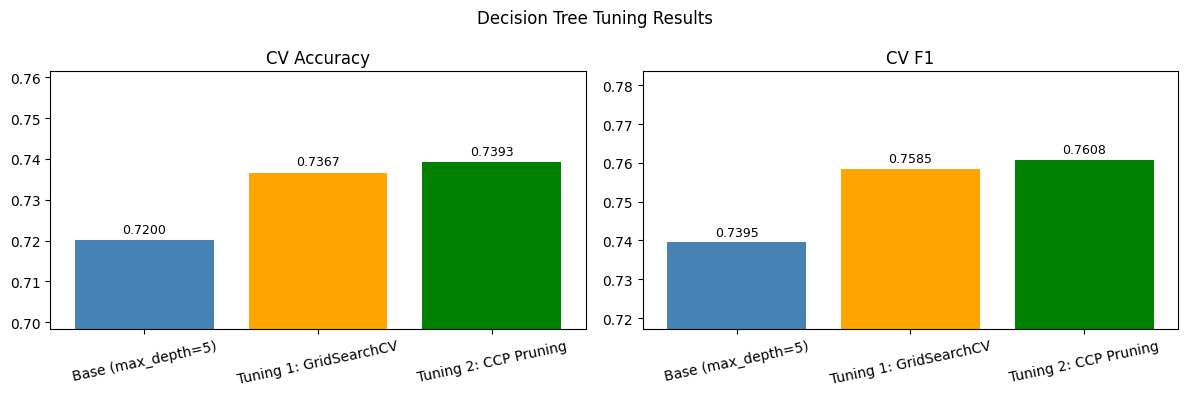

In [8]:
results = pd.DataFrame({
    'Model':       ['Base (max_depth=5)', 'Tuning 1: GridSearchCV', 'Tuning 2: CCP Pruning'],
    'CV Accuracy': [base_acc, grid_acc, pruned_acc],
    'CV F1':       [base_f1,  grid_f1,  pruned_f1]
})
results['Acc Delta'] = (results['CV Accuracy'] - base_acc).map(lambda x: f'{x:+.4f}')
results['F1 Delta']  = (results['CV F1']       - base_f1 ).map(lambda x: f'{x:+.4f}')
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['CV Accuracy', 'CV F1']):
    bars = ax.bar(results['Model'], results[col], color=['steelblue', 'orange', 'green'])
    ax.set_ylim(results[col].min() * 0.97, results[col].max() * 1.03)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=12)
    for bar, val in zip(bars, results[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Decision Tree Tuning Results')
plt.tight_layout()
plt.show()